In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.decomposition import FactorAnalysis

In [3]:
path = r"C:\Users\Lenovo\Downloads\Tushar_Data_Analysis\Coded_Data_Tushar.xlsx"

df = pd.read_excel(path)

df.head()

,AGE,GENDER,UNIVERSITY,STUDY_LEVEL,INCOME,INCOME_SOURCE,SB1,SB2,SB3,SB4,...,FA2,FA3,FA4,FA5,FA6,RP1,RP2,RP3,RP4,RP5
0,4,1,1,3,1,1,2,3,4,3,...,1,3,3,3,3,4,4,4,4,4
1,3,1,1,3,2,1,2,2,3,4,...,1,2,2,3,4,4,3,4,3,2
2,4,1,1,3,3,2,4,2,5,5,...,1,4,4,4,4,4,4,4,4,4
3,3,1,1,3,2,3,4,5,5,4,...,1,4,4,4,4,4,4,4,4,4
4,3,1,1,3,1,1,3,3,2,3,...,1,4,4,3,4,4,4,4,4,3


In [15]:
SB = df[['SB1','SB2','SB3','SB4','SB5','SB6']]

FL = df[['FL1','FL2','FL3','FL4','FL5','FL6','FL7']]

IC = df[['IC1','IC2','IC3','IC4']]

SI = df[['SI1','SI2','SI3','SI4','SI5']]

FA = df[['FA1','FA2','FA3','FA4','FA5','FA6']]

RP = df[['RP1','RP2','RP3','RP4','RP5']]

In [13]:
def cronbach_alpha(data):

    item_var = data.var(axis=0, ddof=1)
    total_var = data.sum(axis=1).var(ddof=1)

    n = data.shape[1]

    alpha = (n/(n-1))*(1-(item_var.sum()/total_var))

    return alpha

4.4.1 Reliability Analysis

In [17]:
alpha_SB = cronbach_alpha(SB)
alpha_FL = cronbach_alpha(FL)
alpha_IC = cronbach_alpha(IC)
alpha_SI = cronbach_alpha(SI)
alpha_FA = cronbach_alpha(FA)
alpha_RP = cronbach_alpha(RP)

In [21]:
def composite_reliability(loadings):

    loadings = np.array(loadings)

    sum_load = loadings.sum()

    sum_load_sq = sum_load**2

    error = sum(1 - loadings**2)

    CR = sum_load_sq / (sum_load_sq + error)

    return CR

In [35]:
def get_loadings(data):

    fa = FactorAnalysis(n_components=1)

    fa.fit(data)

    loadings = fa.components_[0]

    return loadings

In [33]:
constructs = {
"Saving Behaviour": SB,
"Financial Literacy": FL,
"Income Constraint": IC,
"Social Influence": SI,
"Financial Access": FA,
"Risk Preference": RP
}

results = []

for name, data in constructs.items():

    load = get_loadings(data)

    CR = composite_reliability(load)

    alpha = cronbach_alpha(data)

    results.append([name, data.shape[1], round(alpha,3), round(CR,3)])

reliability_table = pd.DataFrame(results,
columns=["Construct","Items","Cronbach Alpha","Composite Reliability"])

reliability_table

,Construct,Items,Cronbach Alpha,Composite Reliability
0,Saving Behaviour,6,0.834,0.874
1,Financial Literacy,7,0.734,0.725
2,Income Constraint,4,0.472,0.587
3,Social Influence,5,0.664,0.676
4,Financial Access,6,0.678,0.619
5,Risk Preference,5,0.535,0.545


4.4.2 Convergent Validity

AVE Function

In [42]:
def AVE(loadings):

    loadings = np.array(loadings)

    return np.mean(loadings**2)

In [44]:
convergent = []

for name, data in constructs.items():

    load = get_loadings(data)

    ave = AVE(load)

    convergent.append([name, round(np.mean(load),3), round(ave,3)])

convergent_table = pd.DataFrame(convergent,
columns=["Construct","Average Loading","AVE"])

convergent_table

,Construct,Average Loading,AVE
0,Saving Behaviour,-0.728,0.543
1,Financial Literacy,-0.504,0.323
2,Income Constraint,-0.482,0.348
3,Social Influence,-0.539,0.305
4,Financial Access,-0.441,0.283
5,Risk Preference,-0.429,0.230


4.4.3 Discriminant Validity (Fornell-Larcker)

Construct Scores

In [48]:
df["PSB"] = SB.mean(axis=1)

df["FL_score"] = FL.mean(axis=1)

df["IC_score"] = IC.mean(axis=1)

df["SI_score"] = SI.mean(axis=1)

df["FA_score"] = FA.mean(axis=1)

df["RP_score"] = RP.mean(axis=1)

Correlation Matrix

In [51]:
construct_scores = df[['PSB','FL_score','IC_score','SI_score','FA_score','RP_score']]

corr_matrix = construct_scores.corr()

corr_matrix

,PSB,FL_score,IC_score,SI_score,FA_score,RP_score
PSB,1.000000,0.532491,0.431036,0.028076,0.183398,0.182933
FL_score,0.532491,1.000000,0.507176,0.220321,0.144058,0.243180
IC_score,0.431036,0.507176,1.000000,0.207257,0.236533,0.100816
SI_score,0.028076,0.220321,0.207257,1.000000,0.349724,0.321071
FA_score,0.183398,0.144058,0.236533,0.349724,1.000000,0.245150
RP_score,0.182933,0.243180,0.100816,0.321071,0.245150,1.000000


Fornell-Larcker Table

In [54]:
AVE_values = convergent_table["AVE"].values

sqrt_AVE = np.sqrt(AVE_values)

fornell = corr_matrix.copy()

np.fill_diagonal(fornell.values, sqrt_AVE)

fornell

,PSB,FL_score,IC_score,SI_score,FA_score,RP_score
PSB,0.736885,0.532491,0.431036,0.028076,0.183398,0.182933
FL_score,0.532491,0.568331,0.507176,0.220321,0.144058,0.243180
IC_score,0.431036,0.507176,0.589915,0.207257,0.236533,0.100816
SI_score,0.028076,0.220321,0.207257,0.552268,0.349724,0.321071
FA_score,0.183398,0.144058,0.236533,0.349724,0.531977,0.245150
RP_score,0.182933,0.243180,0.100816,0.321071,0.245150,0.479583


4.5 Correlation Analysis

In [57]:
corr_matrix

,PSB,FL_score,IC_score,SI_score,FA_score,RP_score
PSB,1.000000,0.532491,0.431036,0.028076,0.183398,0.182933
FL_score,0.532491,1.000000,0.507176,0.220321,0.144058,0.243180
IC_score,0.431036,0.507176,1.000000,0.207257,0.236533,0.100816
SI_score,0.028076,0.220321,0.207257,1.000000,0.349724,0.321071
FA_score,0.183398,0.144058,0.236533,0.349724,1.000000,0.245150
RP_score,0.182933,0.243180,0.100816,0.321071,0.245150,1.000000


Visualization

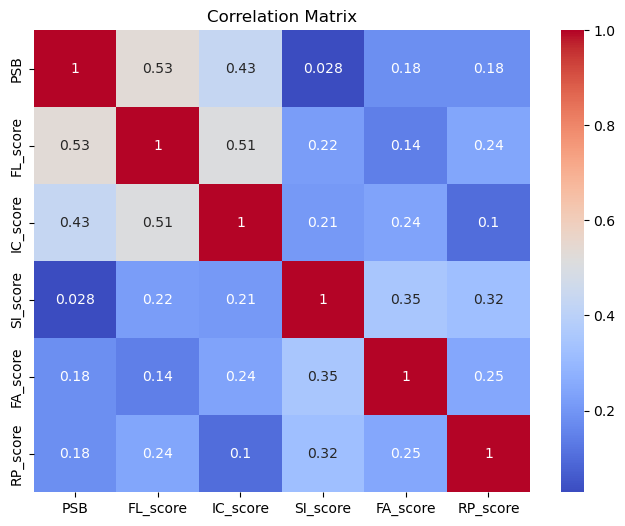

In [60]:
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

4.6 Structural Model (Regression)

Independent Variables

In [68]:
X = df[['FL_score','IC_score','SI_score','FA_score','RP_score']]

Dependent Variable

In [71]:
y = df['PSB']

In [73]:
X = sm.add_constant(X)

In [75]:
model = sm.OLS(y,X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    PSB   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     26.39
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           2.72e-21
Time:                        23:12:08   Log-Likelihood:                -245.49
No. Observations:                 250   AIC:                             503.0
Df Residuals:                     244   BIC:                             524.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4881      0.354      1.378      0.1

4.6.1 Model Fit

In [78]:
model.rsquared

0.3510001726985763

In [80]:
model.rsquared_adj

0.3377009959096128

4.6.2 Path Coefficients Table

In [83]:
results_table = pd.DataFrame({

"Variable": model.params.index,
"Beta": model.params.values,
"t-value": model.tvalues.values,
"p-value": model.pvalues.values

})

results_table

,Variable,Beta,t-value,p-value
0,const,0.488123,1.377518,1.696144e-01
1,FL_score,0.571546,6.877732,5.073278e-11
2,IC_score,0.273764,3.551215,4.600594e-04
3,SI_score,-0.213652,-3.077969,2.322230e-03
4,FA_score,0.173923,1.968913,5.009485e-02
5,RP_score,0.114755,1.558918,1.203120e-01


4.7 Hypothesis Testing Table

In [86]:
hypothesis = results_table.iloc[1:].copy()

hypothesis["Hypothesis"] = [
"H1: Financial Literacy → PSB",
"H2: Income Constraint → PSB",
"H3: Social Influence → PSB",
"H4: Financial Access → PSB",
"H5: Risk Preference → PSB"
]

hypothesis["Result"] = hypothesis["p-value"].apply(lambda x: "Supported" if x < 0.05 else "Not Supported")

hypothesis

,Variable,Beta,t-value,p-value,Hypothesis,Result
1,FL_score,0.571546,6.877732,5.073278e-11,H1: Financial Literacy → PSB,Supported
2,IC_score,0.273764,3.551215,4.600594e-04,H2: Income Constraint → PSB,Supported
3,SI_score,-0.213652,-3.077969,2.322230e-03,H3: Social Influence → PSB,Supported
4,FA_score,0.173923,1.968913,5.009485e-02,H4: Financial Access → PSB,Not Supported
5,RP_score,0.114755,1.558918,1.203120e-01,H5: Risk Preference → PSB,Not Supported
